In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [2]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print(X_train.shape, y_train.shape)

(50000, 32, 32, 3) (50000, 1)


In [3]:
model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(MaxPooling2D())

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D())

model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                   │ (None, 30, 30, 32)       │           896 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)      │ (None, 15, 15, 32)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)                 │ (None, 13, 13, 64)       │        18,496 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)    │ (None, 6, 6, 64)         │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ flatten (Flatten)                 │ (None, 2304)             │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense (Dense)                     │ (None, 128)              │       295,040 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_1 (Dense)                   │ (None, 10)               │         1,290 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.4637 - loss: 1.4911 - val_accuracy: 0.5678 - val_loss: 1.2378
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.5949 - loss: 1.1497 - val_accuracy: 0.6263 - val_loss: 1.0838
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.6446 - loss: 1.0151 - val_accuracy: 0.6434 - val_loss: 1.0334
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.6732 - loss: 0.9347 - val_accuracy: 0.6533 - val_loss: 1.0124
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.7000 - loss: 0.8581 - val_accuracy: 0.6794 - val_loss: 0.9408


In [5]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


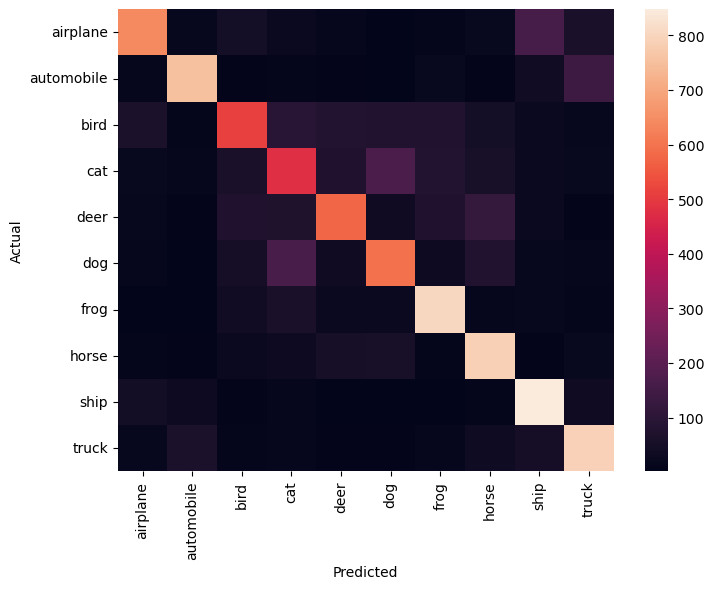

              precision    recall  f1-score   support

    airplane       0.77      0.64      0.70      1000
  automobile       0.83      0.75      0.79      1000
        bird       0.62      0.51      0.56      1000
         cat       0.50      0.48      0.49      1000
        deer       0.66      0.57      0.61      1000
         dog       0.60      0.59      0.60      1000
        frog       0.72      0.80      0.76      1000
       horse       0.67      0.79      0.72      1000
        ship       0.70      0.85      0.76      1000
       truck       0.71      0.79      0.75      1000

    accuracy                           0.68     10000
   macro avg       0.68      0.68      0.67     10000
weighted avg       0.68      0.68      0.67     10000



In [6]:
cm = confusion_matrix(y_test.flatten(), y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=False, xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test.flatten(), y_pred_classes,
                            target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Predicted: ship
Actual: ship


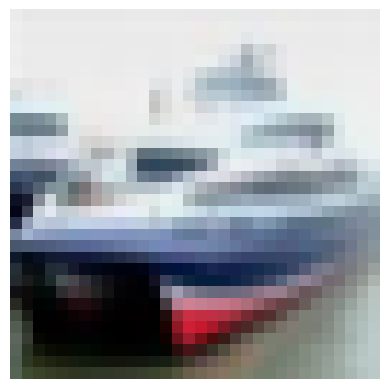

In [12]:
idx = 1

plt.imshow(X_test[idx])
plt.axis("off")

pred = model.predict(X_test[idx:idx+1])
pred_class = class_names[np.argmax(pred)]

print("Predicted:", pred_class)
print("Actual:", class_names[y_test[idx][0]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Predicted: cat
Actual: cat


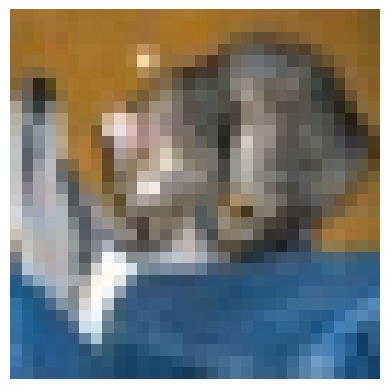

In [11]:
idx = 0

plt.imshow(X_test[idx])
plt.axis("off")

pred = model.predict(X_test[idx:idx+1])
pred_class = class_names[np.argmax(pred)]
print("Predicted:", pred_class)
print("Actual:", class_names[y_test[idx][0]])